In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
data=pd.read_csv("churn_data.csv")
data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.dtypes

customerID           object
tenure                int64
PhoneService         object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
data["PhoneService"].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [5]:
data["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [6]:
data["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [7]:
data["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [8]:
data.shape

(7043, 9)

In [9]:
data.isna().sum()

customerID          0
tenure              0
PhoneService        0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
data.select_dtypes(include=["object"]).columns

Index(['customerID', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoder = {}

for column in data.select_dtypes(include=["object"]).columns:
    if column != "customerID":
        label_encoder[column] = LabelEncoder()
        data[column] = label_encoder[column].fit_transform(data[column])

In [12]:
data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,0,1,2,29.85,2505,0
1,5575-GNVDE,34,1,1,0,3,56.95,1466,0
2,3668-QPYBK,2,1,0,1,3,53.85,157,1
3,7795-CFOCW,45,0,1,0,0,42.30,1400,0
4,9237-HQITU,2,1,0,1,2,70.70,925,1


In [13]:
x=data.drop(columns=['customerID','Churn'])
y=data['Churn']
x.head()

,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,0,1,2,29.85,2505
1,34,1,1,0,3,56.95,1466
2,2,1,0,1,3,53.85,157
3,45,0,1,0,0,42.30,1400
4,2,1,0,1,2,70.70,925


In [14]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
x_train.shape,x_test.shape

((5634, 7), (1409, 7))

In [17]:
y_train.shape,y_test.shape

((5634,), (1409,))

In [18]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [19]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [20]:
y_pred

array([0, 0, 0, ..., 0, 0, 1])

In [21]:
y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

In [22]:
from sklearn.feature_selection import RFE
rfe_model=LogisticRegression()
rfe=RFE(estimator=rfe_model,n_features_to_select=5)

In [23]:
rfe.fit(x_train,y_train)
selected_features=rfe.support_
x_train_rfe=rfe.transform(x_train)
x_test_rfe=rfe.transform(x_test)
model.fit(x_train_rfe,y_train)
y_pred_rfe=model.predict(x_test_rfe)

In [24]:
y_pred_rfe

array([0, 0, 0, ..., 0, 0, 1])

In [25]:
from sklearn.metrics import confusion_matrix,accuracy_score
cof_matrix=confusion_matrix(y_test,y_pred_rfe)
cof_matrix

array([[938,  98],
       [172, 201]])

In [26]:
accuracy_score(y_test,y_pred_rfe)

0.808374733853797

In [27]:
from sklearn.metrics import recall_score
sensitivity=recall_score(y_test,y_pred_rfe)
sensitivity

0.5388739946380697

In [28]:
tn,fp,fn,tp=confusion_matrix(y_test,y_pred_rfe).ravel()
specificity=tn/(tn+fp)
specificity

np.float64(0.9054054054054054)

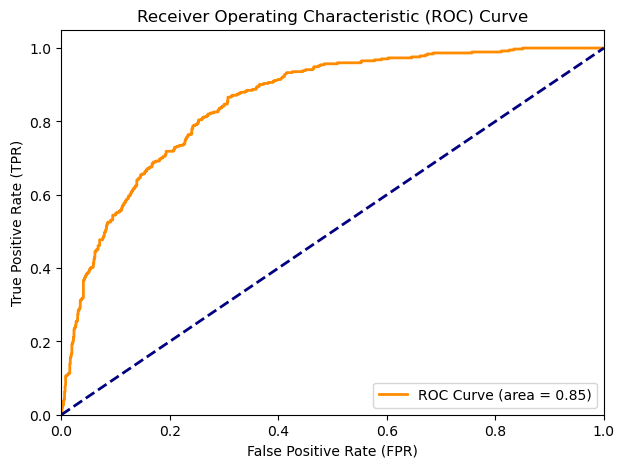

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Calculate FPR, TPR, and Thresholds
y_pred_proba = model.predict_proba(x_test_rfe)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 2. Calculate the actual AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# 3. Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC Curve (area = %0.2f)" % auc_score)

# 4. Plot the random guess baseline (diagonal line)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

# 5. Customize the plot labels and legend
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")

plt.show()

In [31]:
from sklearn.metrics import precision_score
precision=precision_score(y_test,y_pred_rfe)
recall=recall_score(y_test,y_pred_rfe)
precision,recall

(0.6722408026755853, 0.5388739946380697)